In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE

In [2]:
data_train = pd.read_csv('Promotion_train.csv')


# Data_train Preproccessing

In [3]:
data_train.head()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won?,avg_training_score,is_promoted
0,65438,Sales & Marketing,region_7,Master's & above,f,sourcing,1,35,5.0,8,0,49,0
1,65141,Operations,region_22,Bachelor's,m,other,1,30,5.0,4,0,60,0
2,7513,Sales & Marketing,region_19,Bachelor's,m,sourcing,1,34,3.0,7,0,50,0
3,2542,Sales & Marketing,region_23,Bachelor's,m,other,2,39,1.0,10,0,50,0
4,48945,Technology,region_26,Bachelor's,m,other,1,45,3.0,2,0,73,0


In [4]:
data_train['is_promoted'].value_counts()

is_promoted
0    50140
1     4668
Name: count, dtype: int64

In [5]:
data_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54808 entries, 0 to 54807
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   employee_id           54808 non-null  int64  
 1   department            54808 non-null  object 
 2   region                54808 non-null  object 
 3   education             52399 non-null  object 
 4   gender                54808 non-null  object 
 5   recruitment_channel   54808 non-null  object 
 6   no_of_trainings       54808 non-null  int64  
 7   age                   54808 non-null  int64  
 8   previous_year_rating  50684 non-null  float64
 9   length_of_service     54808 non-null  int64  
 10  awards_won?           54808 non-null  int64  
 11  avg_training_score    54808 non-null  int64  
 12  is_promoted           54808 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 5.4+ MB


In [6]:
data_train = data_train.drop(columns=['employee_id', 'region', 'gender'], errors='ignore', axis=1)

In [7]:
data_train

,department,education,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won?,avg_training_score,is_promoted
0,Sales & Marketing,Master's & above,sourcing,1,35,5.0,8,0,49,0
1,Operations,Bachelor's,other,1,30,5.0,4,0,60,0
2,Sales & Marketing,Bachelor's,sourcing,1,34,3.0,7,0,50,0
3,Sales & Marketing,Bachelor's,other,2,39,1.0,10,0,50,0
4,Technology,Bachelor's,other,1,45,3.0,2,0,73,0
...,...,...,...,...,...,...,...,...,...,...
54803,Technology,Bachelor's,sourcing,1,48,3.0,17,0,78,0
54804,Operations,Master's & above,other,1,37,2.0,6,0,56,0
54805,Analytics,Bachelor's,other,1,27,5.0,3,0,79,0
54806,Sales & Marketing,NaN,sourcing,1,29,1.0,2,0,45,0


In [8]:
data_train = data_train.drop_duplicates()

In [9]:
data_train

,department,education,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won?,avg_training_score,is_promoted
0,Sales & Marketing,Master's & above,sourcing,1,35,5.0,8,0,49,0
1,Operations,Bachelor's,other,1,30,5.0,4,0,60,0
2,Sales & Marketing,Bachelor's,sourcing,1,34,3.0,7,0,50,0
3,Sales & Marketing,Bachelor's,other,2,39,1.0,10,0,50,0
4,Technology,Bachelor's,other,1,45,3.0,2,0,73,0
...,...,...,...,...,...,...,...,...,...,...
54803,Technology,Bachelor's,sourcing,1,48,3.0,17,0,78,0
54804,Operations,Master's & above,other,1,37,2.0,6,0,56,0
54805,Analytics,Bachelor's,other,1,27,5.0,3,0,79,0
54806,Sales & Marketing,NaN,sourcing,1,29,1.0,2,0,45,0


In [10]:
data_train.isnull().sum()

department                 0
education               2243
recruitment_channel        0
no_of_trainings            0
age                        0
previous_year_rating    2694
length_of_service          0
awards_won?                0
avg_training_score         0
is_promoted                0
dtype: int64

In [11]:
# data_train = data_train.dropna()
data_train['previous_year_rating'] = data_train['previous_year_rating'].fillna(data_train['previous_year_rating'].median())
data_train['education'] = data_train['education'].fillna(data_train['education'].mode()[0])

C:\Users\user\AppData\Local\Temp\ipykernel_24248\877804081.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_train['previous_year_rating'] = data_train['previous_year_rating'].fillna(data_train['previous_year_rating'].median())
C:\Users\user\AppData\Local\Temp\ipykernel_24248\877804081.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_train['education'] = data_train['education'].fillna(data_train['education'].mode()[0])


In [12]:
data_train.isnull().sum()

department              0
education               0
recruitment_channel     0
no_of_trainings         0
age                     0
previous_year_rating    0
length_of_service       0
awards_won?             0
avg_training_score      0
is_promoted             0
dtype: int64

In [13]:
data_train['is_promoted'].value_counts()

is_promoted
0    44139
1     4611
Name: count, dtype: int64

In [14]:
data_train.head(10)

,department,education,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won?,avg_training_score,is_promoted
0,Sales & Marketing,Master's & above,sourcing,1,35,5.0,8,0,49,0
1,Operations,Bachelor's,other,1,30,5.0,4,0,60,0
2,Sales & Marketing,Bachelor's,sourcing,1,34,3.0,7,0,50,0
3,Sales & Marketing,Bachelor's,other,2,39,1.0,10,0,50,0
4,Technology,Bachelor's,other,1,45,3.0,2,0,73,0
5,Analytics,Bachelor's,sourcing,2,31,3.0,7,0,85,0
6,Operations,Bachelor's,other,1,31,3.0,5,0,59,0
7,Operations,Master's & above,sourcing,1,33,3.0,6,0,63,0
8,Analytics,Bachelor's,other,1,28,4.0,5,0,83,0
9,Sales & Marketing,Master's & above,sourcing,1,32,5.0,5,0,54,0


In [15]:
data_train['department'].unique()

array(['Sales & Marketing', 'Operations', 'Technology', 'Analytics',
       'R&D', 'Procurement', 'Finance', 'HR', 'Legal'], dtype=object)

In [16]:
data_train['education'].unique()

array(["Master's & above", "Bachelor's", 'Below Secondary'], dtype=object)

In [17]:
# maping "Education"
data_train['education'] = data_train['education'].map({"Master's & above":3, "Bachelor's":2, "Below Secondary":1})

C:\Users\user\AppData\Local\Temp\ipykernel_24248\641619021.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_train['education'] = data_train['education'].map({"Master's & above":3, "Bachelor's":2, "Below Secondary":1})


In [18]:
#✔️✔️✔️
data_train['education'].unique()

array([3, 2, 1])

In [19]:
data_train['recruitment_channel'].unique()

array(['sourcing', 'other', 'referred'], dtype=object)

In [48]:
# Maping recruitment_channel
data_train['recruitment_channel'] = data_train['recruitment_channel'].map({"sourcing": 3, "referred":2, 'other':1})



In [49]:
#✔️✔️✔️
data_train['recruitment_channel'].unique()

array([nan])

department_Feature == categorical --> Numerical

In [50]:
# encoder = LabelEncoder()
# data_train['department'] = encoder.fit_transform(data_train['department'])
data_train = pd.get_dummies(data_train ,columns=['department'], drop_first=True)

KeyError: "None of [Index(['department'], dtype='object')] are in the [columns]"

In [ ]:
data_train.head(10)

,education,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won?,avg_training_score,is_promoted,department_Finance,department_HR,department_Legal,department_Operations,department_Procurement,department_R&D,department_Sales & Marketing,department_Technology
0,3,3,1,35,5.0,8,0,49,0,False,False,False,False,False,False,True,False
1,2,1,1,30,5.0,4,0,60,0,False,False,False,True,False,False,False,False
2,2,3,1,34,3.0,7,0,50,0,False,False,False,False,False,False,True,False
3,2,1,2,39,1.0,10,0,50,0,False,False,False,False,False,False,True,False
4,2,1,1,45,3.0,2,0,73,0,False,False,False,False,False,False,False,True
5,2,3,2,31,3.0,7,0,85,0,False,False,False,False,False,False,False,False
6,2,1,1,31,3.0,5,0,59,0,False,False,False,True,False,False,False,False
7,3,3,1,33,3.0,6,0,63,0,False,False,False,True,False,False,False,False
8,2,1,1,28,4.0,5,0,83,0,False,False,False,False,False,False,False,False
9,3,3,1,32,5.0,5,0,54,0,False,False,False,False,False,False,True,False


In [24]:
data_train.describe()

,education,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won?,avg_training_score,is_promoted
count,48750.000000,48750.000000,48750.000000,48750.000000,48750.000000,48750.000000,48750.000000,48750.000000,48750.000000
mean,2.277497,1.874256,1.274728,35.316615,3.309292,6.095528,0.025969,63.736964,0.094585
std,0.480944,0.980425,0.633913,7.806473,1.234861,4.356882,0.159045,13.448000,0.292643
min,1.000000,1.000000,1.000000,20.000000,1.000000,1.000000,0.000000,39.000000,0.000000
25%,2.000000,1.000000,1.000000,30.000000,3.000000,3.000000,0.000000,51.000000,0.000000
50%,2.000000,1.000000,1.000000,34.000000,3.000000,5.000000,0.000000,61.000000,0.000000
75%,3.000000,3.000000,1.000000,39.000000,4.000000,8.000000,0.000000,76.000000,0.000000
max,3.000000,3.000000,10.000000,60.000000,5.000000,37.000000,1.000000,99.000000,1.000000


In [25]:
data_train.head()

,education,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won?,avg_training_score,is_promoted,department_Finance,department_HR,department_Legal,department_Operations,department_Procurement,department_R&D,department_Sales & Marketing,department_Technology
0,3,3,1,35,5.0,8,0,49,0,False,False,False,False,False,False,True,False
1,2,1,1,30,5.0,4,0,60,0,False,False,False,True,False,False,False,False
2,2,3,1,34,3.0,7,0,50,0,False,False,False,False,False,False,True,False
3,2,1,2,39,1.0,10,0,50,0,False,False,False,False,False,False,True,False
4,2,1,1,45,3.0,2,0,73,0,False,False,False,False,False,False,False,True


# Data Visualization --> Histogram

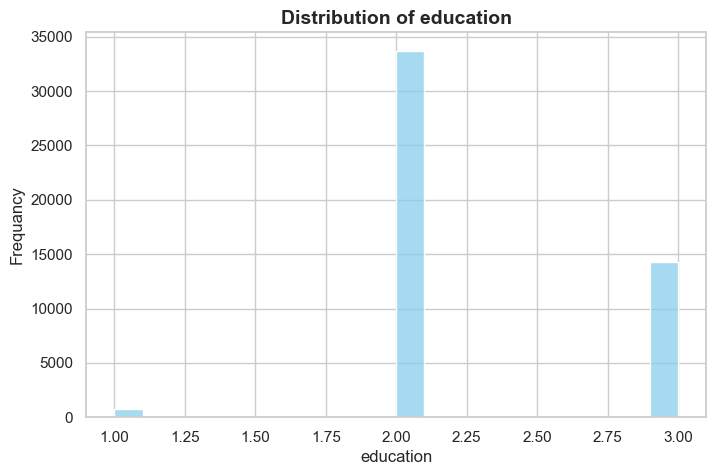

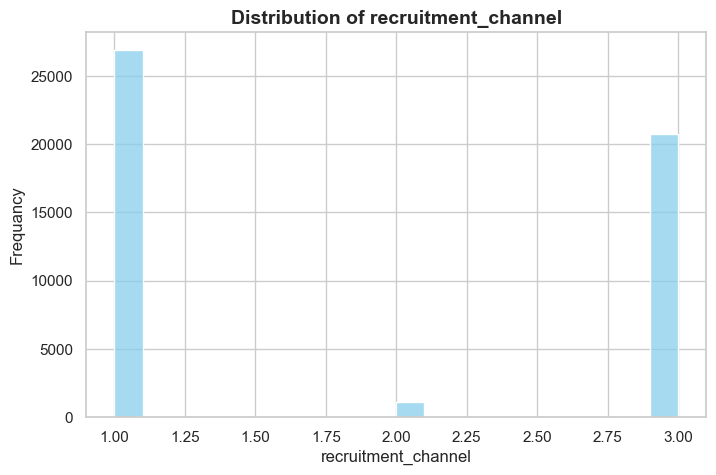

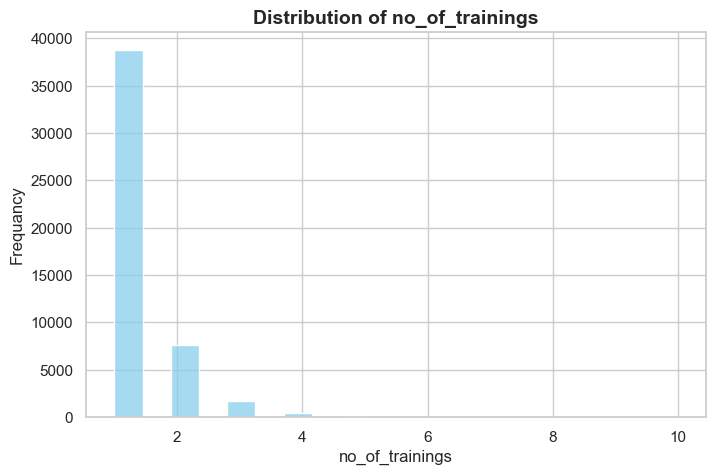

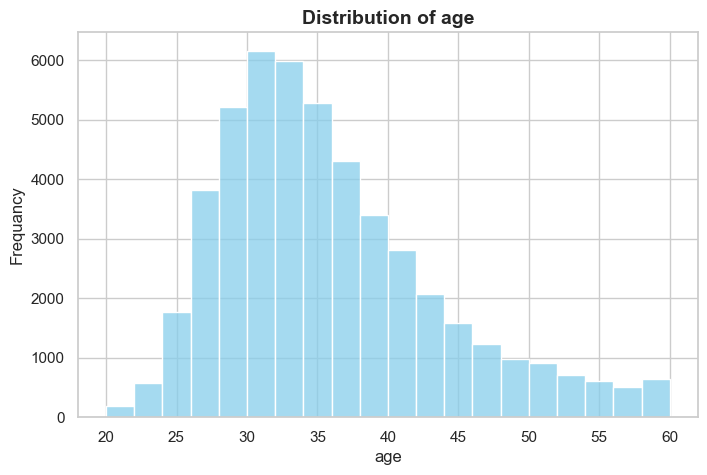

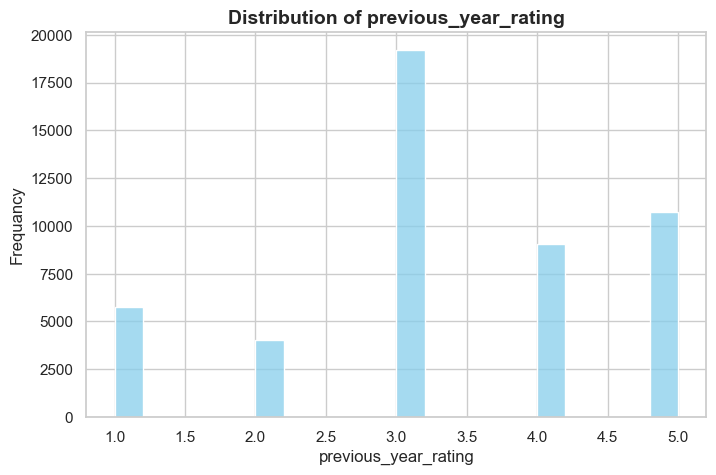

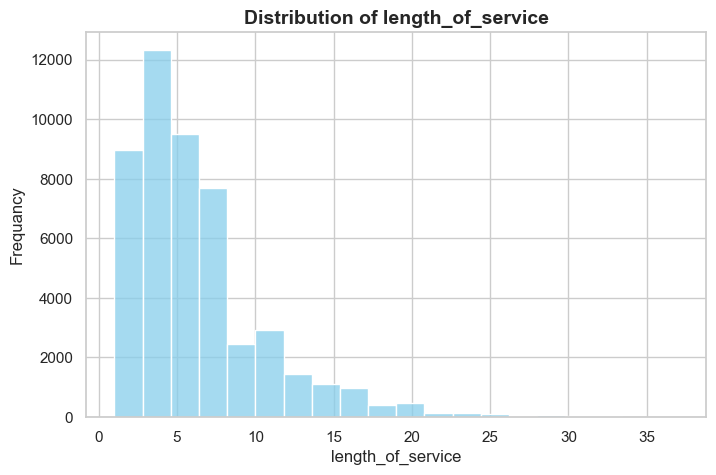

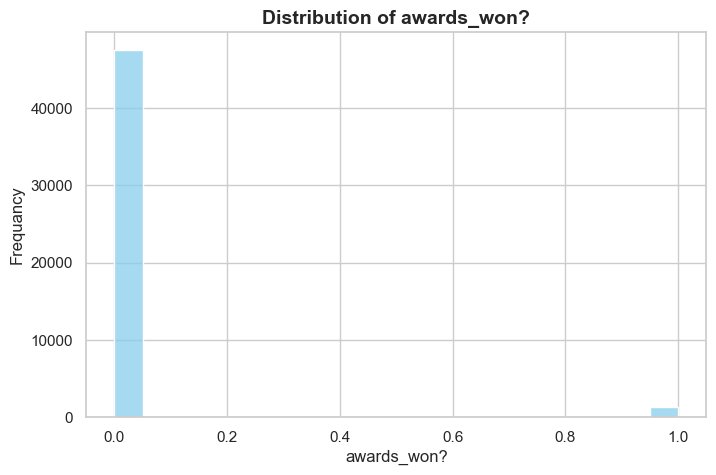

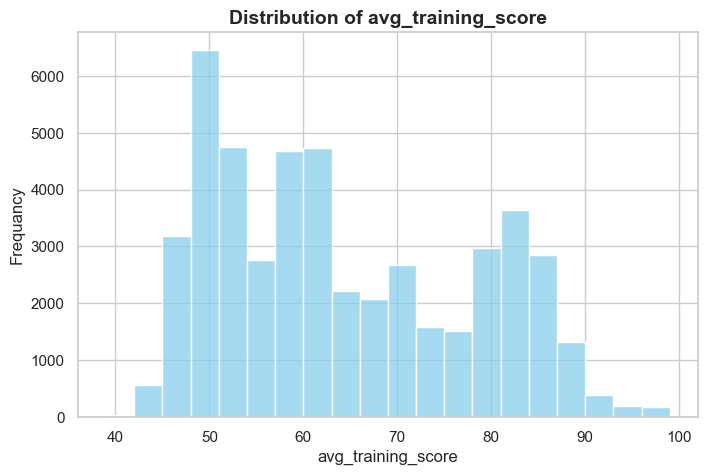

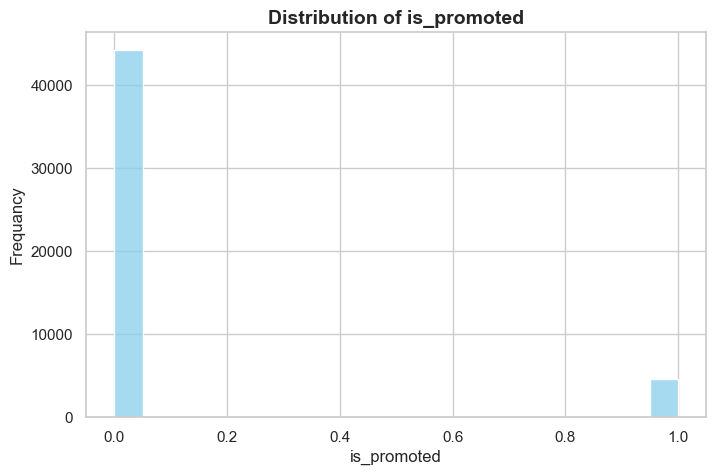

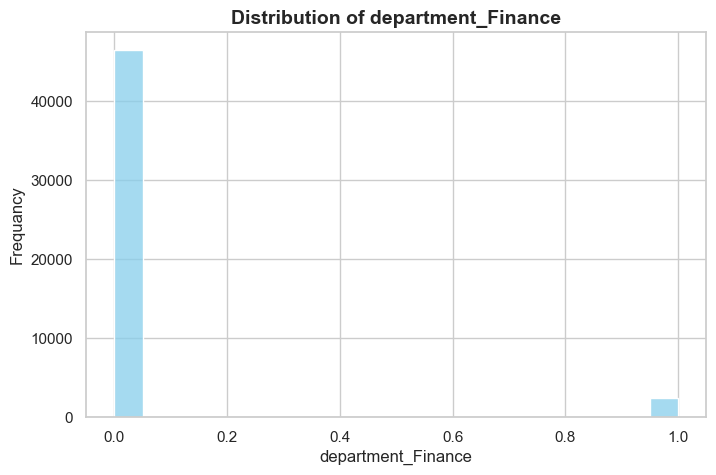

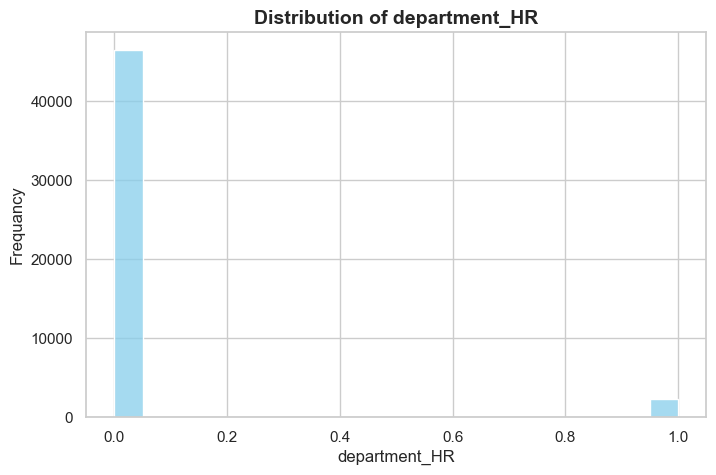

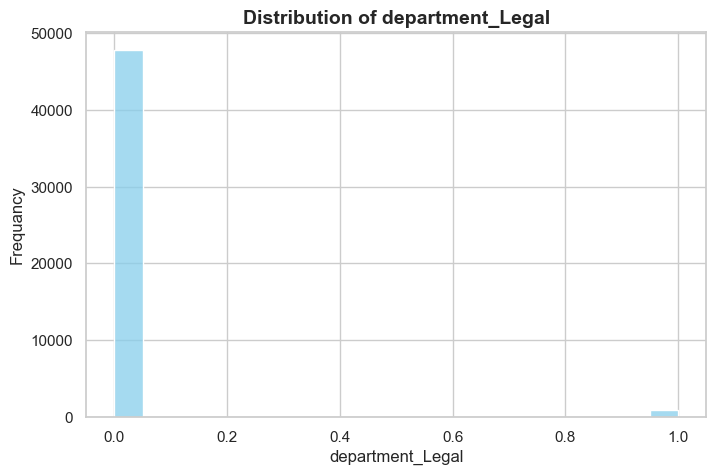

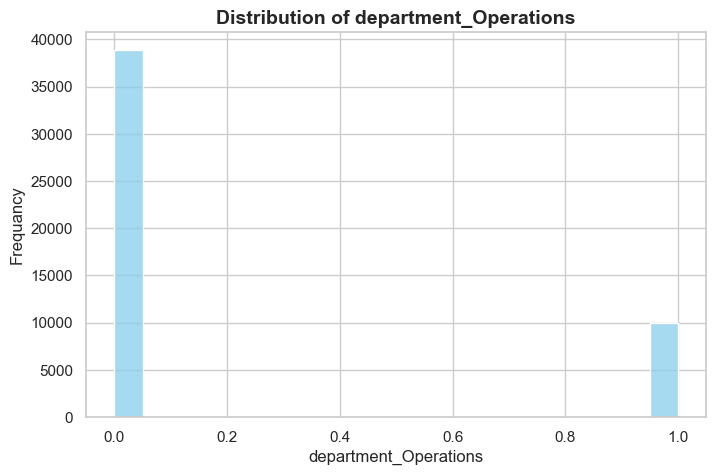

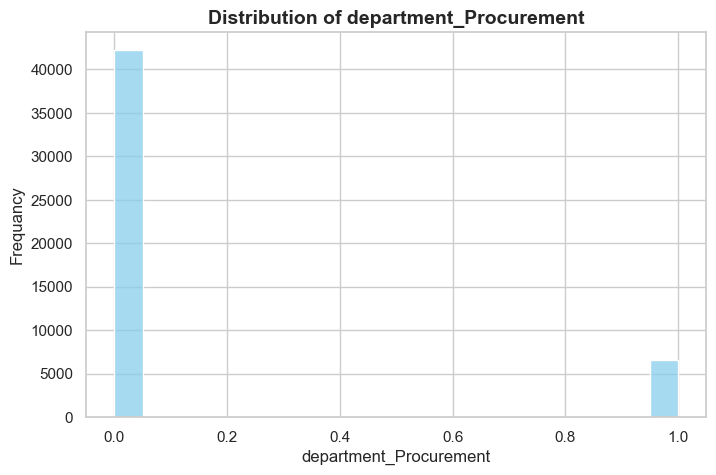

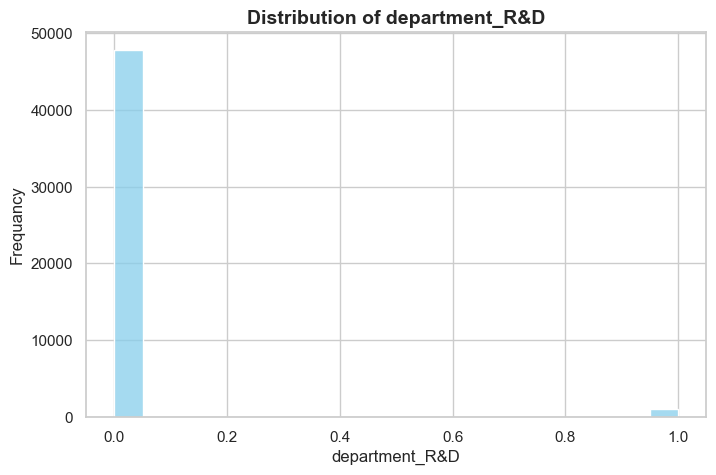

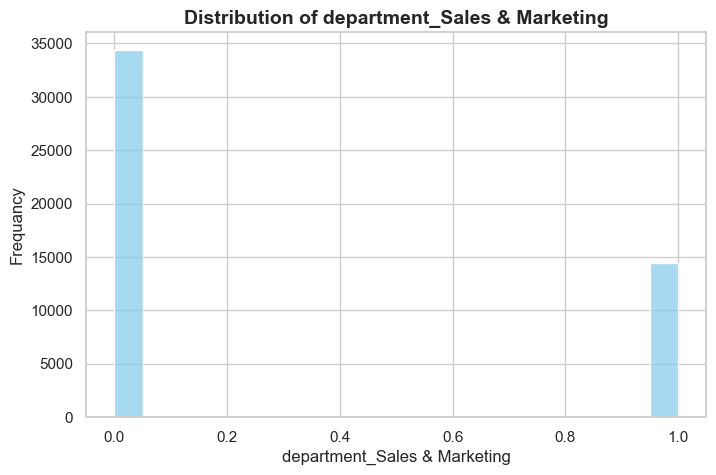

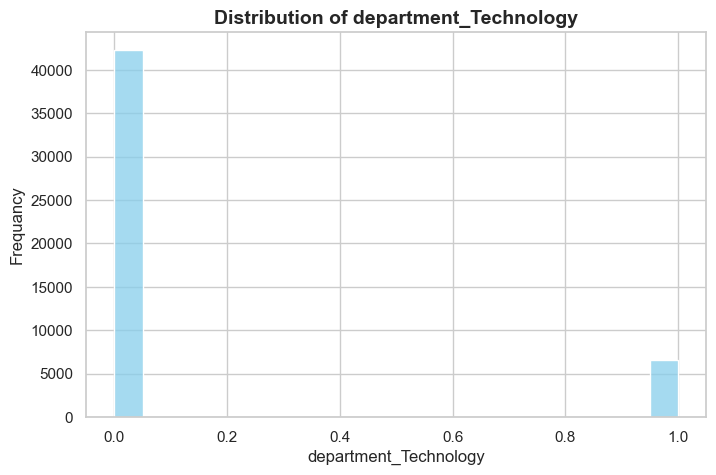

In [26]:
for col in data_train.columns:
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(8, 5))
    sns.histplot(data=data_train, x=col,  color='skyblue', bins=20)
    plt.title(f'Distribution of {col}', fontsize=14, fontweight='bold')
    plt.xlabel(f'{col}', fontsize=12)
    plt.ylabel('Frequancy', fontsize=12)

    plt.show()

# Under Sample the target

In [27]:
x = data_train.drop(columns=['is_promoted'])
y = data_train['is_promoted']

In [28]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [29]:
# under_sampler = RandomUnderSampler(sampling_strategy='majority',random_state=42)
# x, y = under_sampler.fit_resample(x , y)
under_sampler = SMOTE( random_state=42)


x_train, y_train = under_sampler.fit_resample(x_train, y_train)

In [30]:
y_train.value_counts()

is_promoted
0    35317
1    35317
Name: count, dtype: int64

In [31]:
x_train.isnull().sum()

education                       0
recruitment_channel             0
no_of_trainings                 0
age                             0
previous_year_rating            0
length_of_service               0
awards_won?                     0
avg_training_score              0
department_Finance              0
department_HR                   0
department_Legal                0
department_Operations           0
department_Procurement          0
department_R&D                  0
department_Sales & Marketing    0
department_Technology           0
dtype: int64

In [32]:
y_train.isnull().sum()

np.int64(0)

# Correlation Heatmap

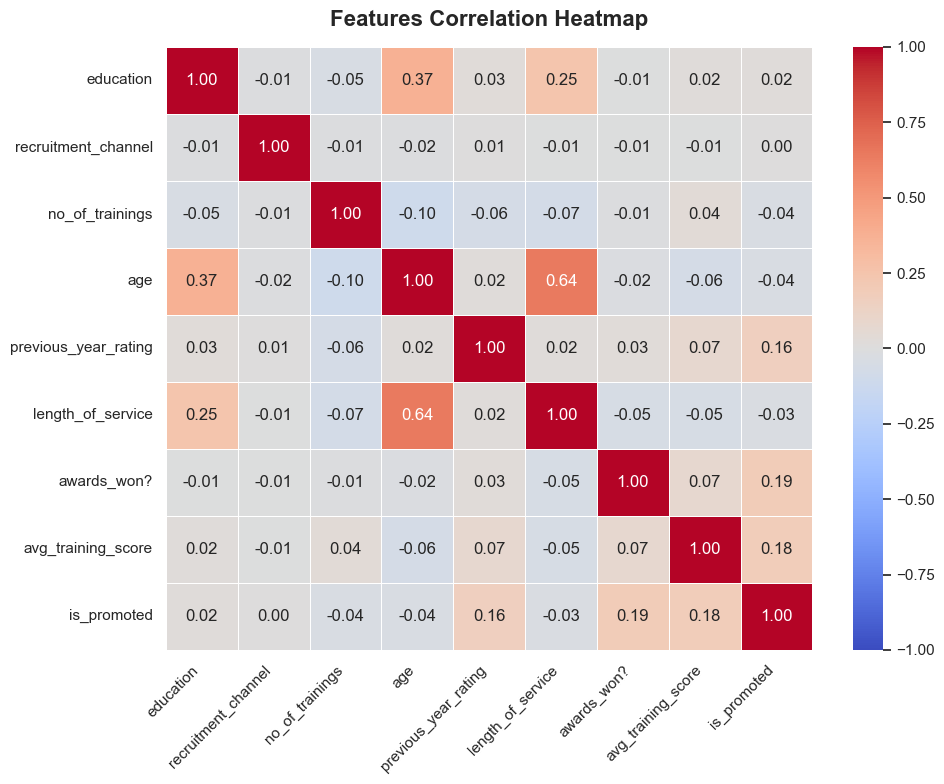

In [33]:

corr_matrix = data_train.select_dtypes(include=['float64', 'int64']).corr()


plt.figure(figsize=(10, 8))

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)

plt.title('Features Correlation Heatmap', fontsize=16, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right') 
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

# Train The Models

## Random Forest Model

In [34]:
model = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',
    max_depth=None,
    bootstrap=True,
    random_state=42
)
model.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.

In [35]:
predict = model.predict(x_test)
report1=classification_report(y_test, predict)
print(classification_report(y_test, predict))

              precision    recall  f1-score   support

           0       0.94      0.94      0.94      8822
           1       0.41      0.43      0.42       928

    accuracy                           0.89      9750
   macro avg       0.68      0.68      0.68      9750
weighted avg       0.89      0.89      0.89      9750



# Scalling features

In [36]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)
x.isnull().sum()

education                       0
recruitment_channel             0
no_of_trainings                 0
age                             0
previous_year_rating            0
length_of_service               0
awards_won?                     0
avg_training_score              0
department_Finance              0
department_HR                   0
department_Legal                0
department_Operations           0
department_Procurement          0
department_R&D                  0
department_Sales & Marketing    0
department_Technology           0
dtype: int64

## Logistic Regression Model

In [37]:
model2= LogisticRegression(max_iter=100 ,random_state=42)
model2.fit(x_train_scaled, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solve

In [38]:
predict2 = model2.predict(x_test_scaled)

In [39]:
report2=classification_report(y_test, predict2)
print(classification_report(y_test, predict2))

              precision    recall  f1-score   support

           0       0.95      0.81      0.88      8822
           1       0.24      0.57      0.34       928

    accuracy                           0.79      9750
   macro avg       0.59      0.69      0.61      9750
weighted avg       0.88      0.79      0.82      9750



## KNN Classifier Model

In [40]:
model3 = KNeighborsClassifier(n_neighbors=19)
model3.fit(x_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",19
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [41]:
predict3 = model3.predict(x_test_scaled)
report3=classification_report(y_test, predict3)
print(classification_report(y_test, predict3))

              precision    recall  f1-score   support

           0       0.94      0.84      0.88      8822
           1       0.23      0.48      0.31       928

    accuracy                           0.80      9750
   macro avg       0.59      0.66      0.60      9750
weighted avg       0.87      0.80      0.83      9750



# Naive Bais Model

In [42]:
model4 = GaussianNB()
model4.fit(x_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)number of training samples observed in each class.","ndarray[float64](2,)","[35317.,35317.]"
"class_prior_ class_prior_: ndarray of shape (n_classes,)probability of each class.","ndarray[float64](2,)","[0.5,0.5]"
"classes_ classes_: ndarray of shape (n_classes,)class labels known to the classifier.","ndarray[int64](2,)","[0,1]"
epsilon_ epsilon_: floatabsolute additive value to variances.,float64,2.092e-07
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](16,)","['education','recruitment_channel','no_of_trainings',...,'department_R&D', 'department_Sales & Marketing','department_Technology']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,16
"theta_ theta_: ndarray of shape (n_classes, n_features)mean of each feature per class.","ndarray[float64](2, 16)","[[2.27,1.87,1.28,...,0.02,0.3 ,0.13], [2.17,1.78,1.07,...,0.02,0.33,0.23]]"
"var_ var_: ndarray of shape (n_classes, n_features)Variance of each feature per class... versionadded:: 1.0","ndarray[float64](2, 16)","[[0.23,0.96,0.41,...,0.02,0.21,0.11], [0.18,0.87,0.09,...,0.02,0.22,0.18]]"


In [43]:
predict4 = model4.predict(x_test)
report4=classification_report(y_test, predict4)
print(classification_report(y_test, predict4))

              precision    recall  f1-score   support

           0       0.94      0.63      0.75      8822
           1       0.15      0.60      0.24       928

    accuracy                           0.63      9750
   macro avg       0.54      0.62      0.50      9750
weighted avg       0.86      0.63      0.71      9750



## SVC Model

In [45]:
model5 = SVC(C=1, random_state=42)
model5.fit(x_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


In [46]:
predict5 = model5.predict(x_test)
report5=classification_report(y_test, predict5)
print(classification_report(y_test, predict5))

              precision    recall  f1-score   support

           0       0.95      0.75      0.84      8822
           1       0.20      0.60      0.30       928

    accuracy                           0.73      9750
   macro avg       0.57      0.67      0.57      9750
weighted avg       0.88      0.73      0.78      9750



# Comparison by BarChart between the models


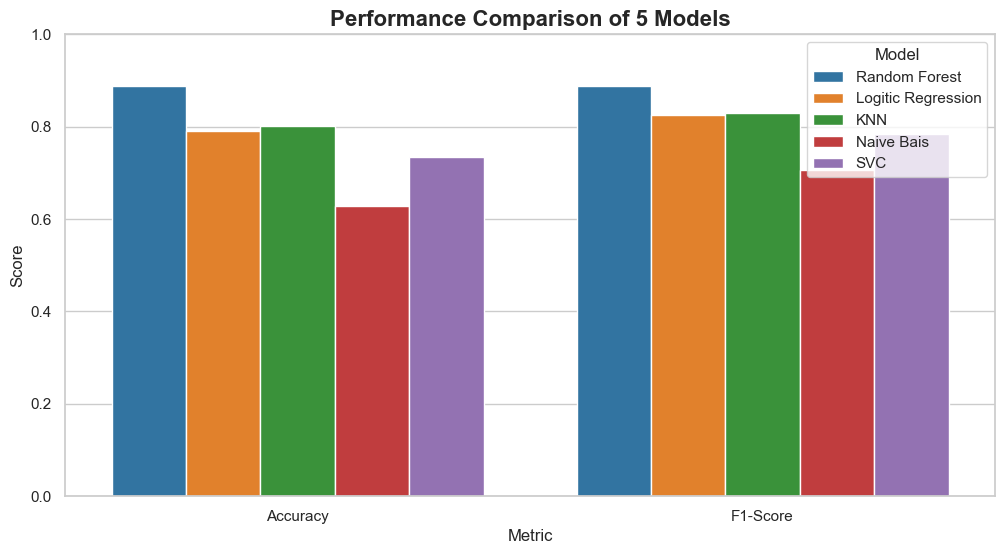

In [51]:
reports= [
    report1, report2, report3, report4, report5
]
model_names = [
    'Random Forest', 'Logitic Regression', 'KNN', 'Naive Bais', 'SVC'
]
data = []
for name, rep in zip(model_names, reports):
    reports = [
        classification_report(y_test, predict, output_dict=True),
        classification_report(y_test, predict2, output_dict=True),
        classification_report(y_test, predict3, output_dict=True),
        classification_report(y_test, predict4, output_dict=True),
        classification_report(y_test, predict5, output_dict=True)
    ]
    model_names = [
        'Random Forest', 'Logitic Regression', 'KNN', 'Naive Bais', 'SVC'
    ]
    data = []
    for name, rep in zip(model_names, reports):
        data.append({
            'Model': name,
            'Accuracy': rep['accuracy'],
            'F1-Score': rep['weighted avg']['f1-score']
        })
data_comp = pd.DataFrame(data)

df_melted = data_comp.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 6))
sns.barplot(data=df_melted, x='Metric', y='Score', hue='Model', palette='tab10')
plt.title('Performance Comparison of 5 Models', fontsize=16, fontweight='bold')
plt.ylim(0, 1.0)
plt.ylabel('Score')
plt.show()

## Export Random Forest Model --> pkl file

In [52]:
import joblib
rf_model = joblib.dump(model ,"Promotion_Model.pkl")